In [43]:
#Load stock data
import pandas as pd

stock_df = pd.read_csv("../data/raw/AAPL.csv")  # adjust filename
stock_df.isnull().sum() #Check for and handle missing values
stock_df.dropna(inplace=True)
stock_df.dtypes
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [44]:
#coloms.s name
print(stock_df.columns)

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')


In [45]:
#Convert Date
stock_df["Date"] = pd.to_datetime(stock_df["Date"])
stock_df = stock_df.sort_values("Date")
stock_df.head()

,Date,Close,High,Low,Open,Volume
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800


In [46]:
#Set price column
price = stock_df["Close"]
print(price.head())

0    2.721686
1    2.836553
2    2.789767
3    2.729484
4    2.780169
Name: Close, dtype: float64


In [47]:
#Moving Averages (SMA & EMA)
from ta.trend import SMAIndicator, EMAIndicator

stock_df["SMA_20"] = SMAIndicator(price, window=20).sma_indicator()
stock_df["EMA_20"] = EMAIndicator(price, window=20).ema_indicator()
stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN


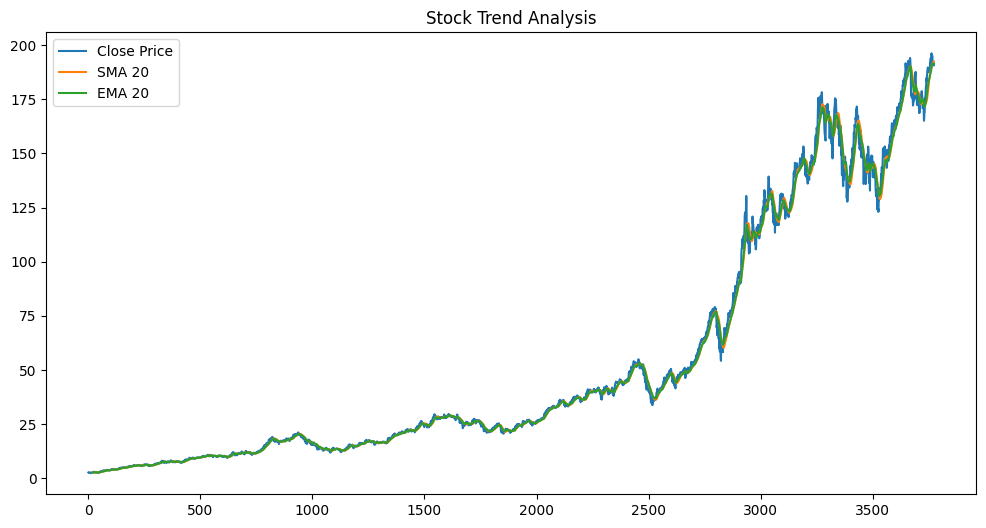

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(stock_df["Close"], label="Close Price")
plt.plot(stock_df["SMA_20"], label="SMA 20")
plt.plot(stock_df["EMA_20"], label="EMA 20")

plt.legend()
plt.title("Stock Trend Analysis")
plt.show()

In [49]:
#RSI (momentum indicator)
from ta.momentum import RSIIndicator

stock_df["RSI"] = RSIIndicator(price, window=14).rsi()
stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,NaN


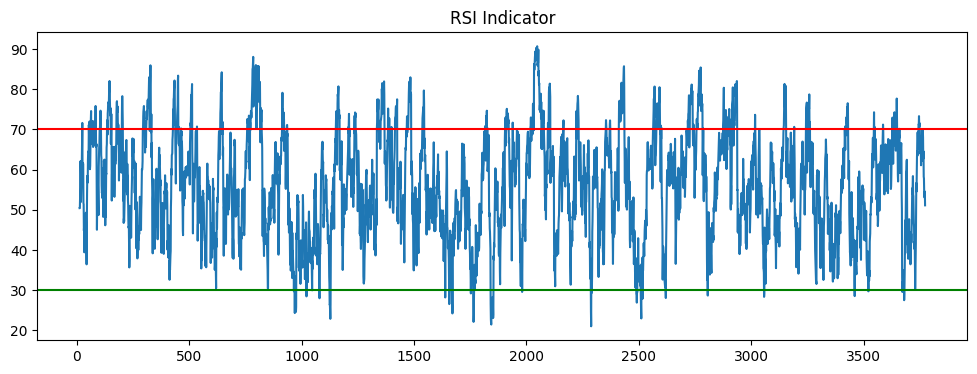

In [50]:
plt.figure(figsize=(12,4))
plt.plot(stock_df["RSI"])
plt.axhline(70, color='red')
plt.axhline(30, color='green')
plt.title("RSI Indicator")
plt.show()

In [51]:
#MACD (trend signal)
from ta.trend import MACD

macd = MACD(price)

stock_df["MACD"] = macd.macd()
stock_df["MACD_signal"] = macd.macd_signal()
stock_df.head()

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI,MACD,MACD_signal
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,NaN,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,NaN,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,NaN,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,NaN,NaN,NaN


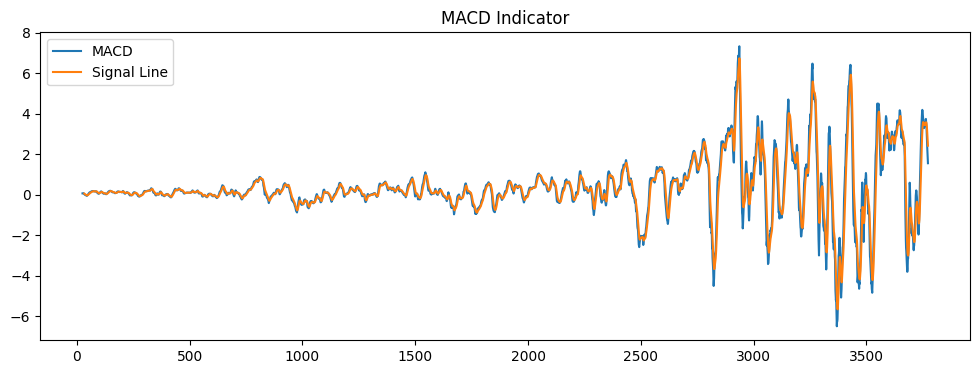

,Date,Close,High,Low,Open,Volume,SMA_20,EMA_20,RSI,MACD,MACD_signal
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,NaN,NaN,NaN,NaN,NaN
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,NaN,NaN,NaN,NaN,NaN
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,NaN,NaN,NaN,NaN,NaN
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,NaN,NaN,NaN,NaN,NaN
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,NaN,NaN,NaN,NaN,NaN


In [52]:
#MACD
plt.figure(figsize=(12,4))
plt.plot(stock_df["MACD"], label="MACD")
plt.plot(stock_df["MACD_signal"], label="Signal Line")
plt.legend()
plt.title("MACD Indicator")
plt.show()
stock_df.head()